## Part B.1 – Train Logistic Regression and Decision Tree

Import Models and Metrics

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import pandas as pd
import matplotlib.pyplot as plt

Load Dataset

In [2]:
df = pd.read_csv("credit_applicants.csv")

print(df.shape)
df.head()

(400, 10)


,applicant_id,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,employment_type,default
0,APP1000,59,41646,4,0.80,17398,2,NaN,salaried,1
1,APP1001,49,119185,0,0.08,58503,3,380.0,salaried,0
2,APP1002,35,38049,0,0.59,8638,1,788.0,salaried,1
3,APP1003,28,113116,0,0.26,8570,2,387.0,salaried,0
4,APP1004,41,112379,2,0.16,70785,3,493.0,salaried,0


Clean Data

In [3]:
from sklearn.model_selection import train_test_split

# X = df.drop(columns=['default','applicant_id'], axis=1)
X = df.drop(columns=['default','applicant_id','employment_type']).fillna(0)
# X=df.fillna(0)

y = df["default"]

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.25,
        stratify=y,
        random_state=42
    )
)


Train Logistic Regression

In [4]:

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Train Decision Tree

In [5]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

# Part B.2 – Generate Predictions

Logistic Regression

In [6]:
lr_pred = lr_model.predict(X_test)

lr_prob = lr_model.predict_proba(
    X_test
)[:,1]

Decision Tree

In [7]:
dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(
    X_test
)[:,1]

# Part B.3 – Confusion Matrices

Logistic Regression

In [8]:
lr_cm = confusion_matrix(
    y_test,
    lr_pred
)

print("Logistic Regression")
print(lr_cm)

Logistic Regression
[[70 10]
 [13  7]]


Decision Tree

In [9]:
dt_cm = confusion_matrix(
    y_test,
    dt_pred
)

print("Decision Tree")
print(dt_cm)

Decision Tree
[[66 14]
 [15  5]]


# Part B.4 – Calculate Evaluation Metrics

In [10]:
def evaluate_model(
        y_true,
        predictions,
        probabilities):

    return {
        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Precision":
            precision_score(
                y_true,
                predictions
            ),

        "Recall":
            recall_score(
                y_true,
                predictions
            ),

        "F1":
            f1_score(
                y_true,
                predictions
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                probabilities
            )
    }

Evaluate Both Models

In [11]:
lr_metrics = evaluate_model(
    y_test,
    lr_pred,
    lr_prob
)

dt_metrics = evaluate_model(
    y_test,
    dt_pred,
    dt_prob
)

# Part B.5 – Comparison Table

In [12]:
comparison = pd.DataFrame(
    [lr_metrics,
     dt_metrics],
    index=[
        "Logistic Regression",
        "Decision Tree"
    ]
)

comparison = comparison.round(4)

print(comparison)

                     Accuracy  Precision  Recall      F1  ROC_AUC
Logistic Regression      0.77     0.4118    0.35  0.3784   0.7031
Decision Tree            0.71     0.2632    0.25  0.2564   0.5375


# Part B.6 – ROC Curve Comparison

In [13]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_prob
)

Plot ROC Curves

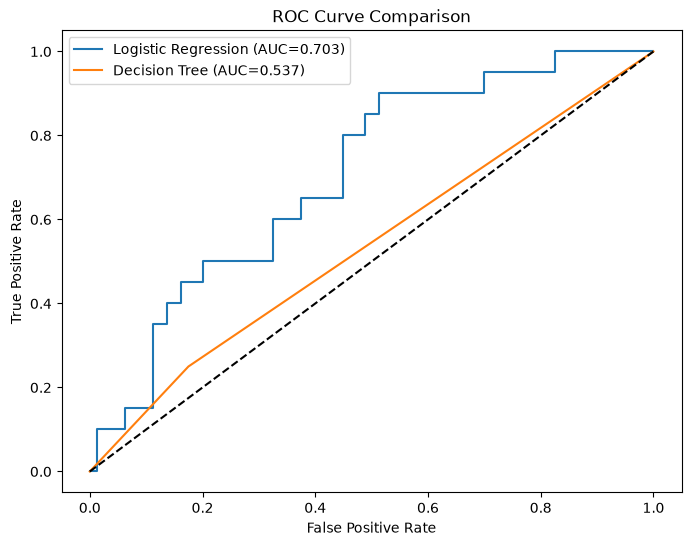

In [14]:
plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test,lr_prob):.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC={roc_auc_score(y_test,dt_prob):.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.savefig(
    "roc_curve_comparison.png"
)

plt.show()

1. confusion_matrix.png

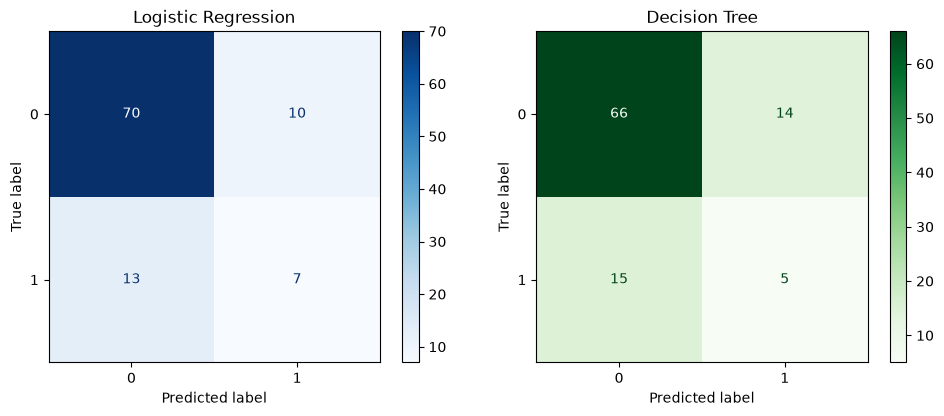

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    ax=axes[1],
    cmap="Greens"
)
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


2. roc_curve.png

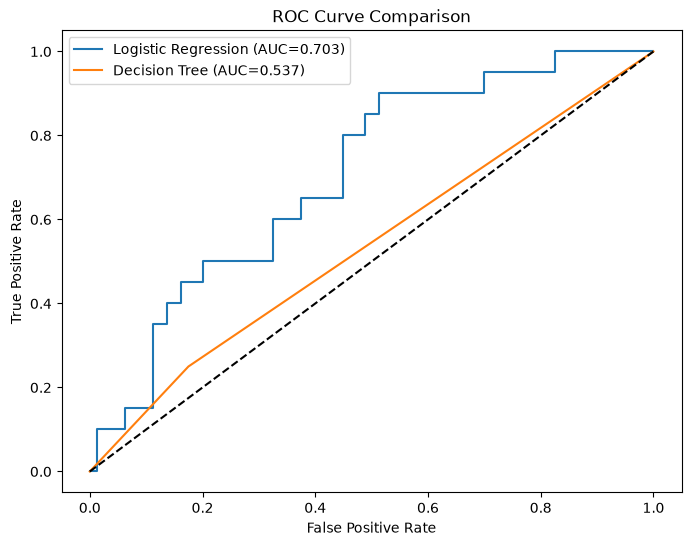

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC={roc_auc_score(y_test, dt_prob):.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("roc_curve.png")
plt.show()

3. feature_importance.png

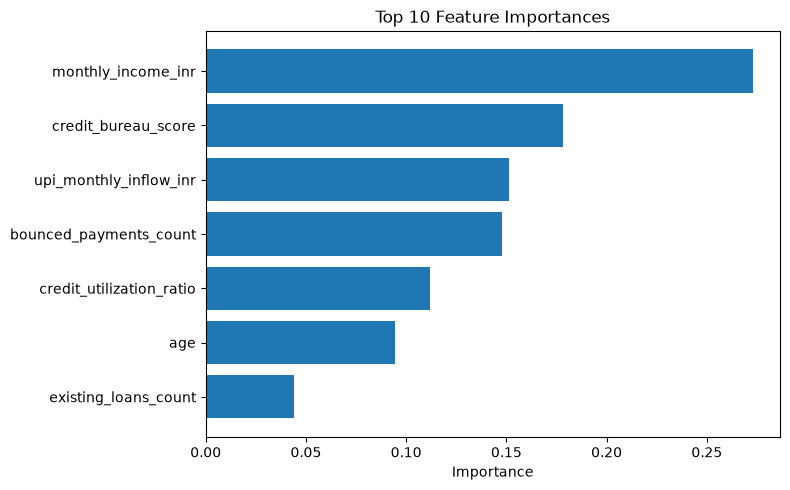

In [17]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("feature_importance.png")
plt.show()

4. anomaly_scatter.png

In [18]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# 1. Ensure behaviour is a Pandas DataFrame
# behaviour = pd.DataFrame(behaviour)
behaviour=df

# anomaly_features = [
#     "txn_hour",
#     "txn_amount_inr",
#     "is_new_device"
# ]

anomaly_features = [
    "age",
    "monthly_income_inr",
    "existing_loans_count",
    "credit_utilization_ratio",
    "upi_monthly_inflow_inr",
    "bounced_payments_count",
    "credit_bureau_score"    
]

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

# This will now work without errors
behaviour["anomaly"] = iso.fit_predict(
    behaviour[anomaly_features]
)

behaviour["anomaly_label"] = behaviour[
    "anomaly"
].map({
    1: "Normal",
    -1: "Anomaly"
})


Scatter Plot

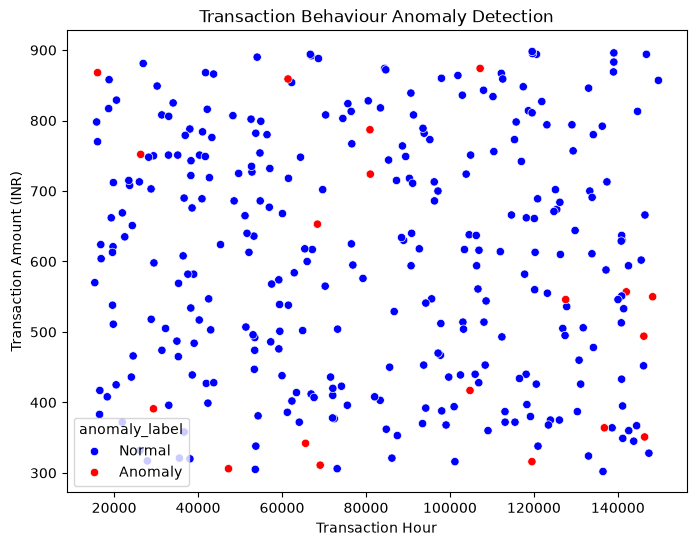

In [19]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=behaviour,
    x="monthly_income_inr",
    y="credit_bureau_score",
    hue="anomaly_label",
    palette={
        "Normal":"blue",
        "Anomaly":"red"
    }
)

plt.title("Transaction Behaviour Anomaly Detection")
plt.xlabel("Transaction Hour")
plt.ylabel("Transaction Amount (INR)")

plt.savefig("anomaly_scatter.png")

plt.show()

# Part B.7 – Risk-Based Pricing Table

Create Probabilities for Entire Dataset

In [20]:
all_probs = lr_model.predict_proba(
    X_test
)[:,1]

risk_df = X_test.copy()

risk_df["actual_default"] = y_test.values

risk_df["pd"] = all_probs

Create 4 Risk Tiers (Quartiles)

In [21]:
risk_df["risk_tier"] = pd.qcut(
    risk_df["pd"],
    q=4,
    labels=[
        "Tier 1 - Lowest Risk",
        "Tier 2 - Low Risk",
        "Tier 3 - Moderate Risk",
        "Tier 4 - Highest Risk"
    ]
)

Assign Interest Rates

In [22]:
rate_map = {

    "Tier 1 - Lowest Risk":
        "10% - 12%",

    "Tier 2 - Low Risk":
        "12% - 15%",

    "Tier 3 - Moderate Risk":
        "15% - 18%",

    "Tier 4 - Highest Risk":
        "18% - 24%"
}

risk_df["interest_rate"] = (
    risk_df["risk_tier"]
    .map(rate_map)
)

# Part B.8 – Calculate Actual Default Rates

In [23]:
risk_pricing = (
    risk_df
    .groupby(
        ["risk_tier",
         "interest_rate"]
    )
    .agg(
        applicants=(
            "actual_default",
            "count"
        ),

        observed_default_rate=(
            "actual_default",
            "mean"
        )
    )
    .reset_index()
)

risk_pricing[
    "observed_default_rate"
] = (
    risk_pricing[
        "observed_default_rate"
    ]
    * 100
).round(2)

print(risk_pricing)

                risk_tier interest_rate  applicants  observed_default_rate
0    Tier 1 - Lowest Risk     10% - 12%          25                    4.0
1       Tier 2 - Low Risk     12% - 15%          25                   20.0
2  Tier 3 - Moderate Risk     15% - 18%          25                   20.0
3   Tier 4 - Highest Risk     18% - 24%          25                   36.0


Monotonicity Check

In [24]:
print(
    risk_pricing[
        [
          "risk_tier",
          "observed_default_rate"
        ]
    ]
)

                risk_tier  observed_default_rate
0    Tier 1 - Lowest Risk                    4.0
1       Tier 2 - Low Risk                   20.0
2  Tier 3 - Moderate Risk                   20.0
3   Tier 4 - Highest Risk                   36.0
